In [1]:
from datasets import load_dataset
import pandas as pd

# Load the dataset from Hugging Face
# This dataset only has a 'train' split
dataset = load_dataset("adityarane/financial-qa-dataset", split='train', verification_mode="no_checks")

# Convert the Dataset object to a pandas DataFrame
df = dataset.to_pandas()

# Display the first few rows of the DataFrame
print(df.head())

/Users/ivanmkc/code/adk-samples/env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


                                           Questions           Answers  \
0  What was the total revenue of Alphabet Inc. in...  $307,394 million   
1  How much did the BMW Group report in trade pay...   €10,932 million   
2  What was the total equity attributable to shar...   €59,324 million   
3  What was the amount of subscribed share capita...   1 million euros   
4  What was the revenue of Mercedes-Benz Group in...  €150,017 million   

                                            Contexts  \
0  Alphabet Inc.\nCONSOLIDATED STATEMENTS OF INCO...   
1  BALANCE SHEET FOR GROUP   \nAND SEGMENTS AT 31...   
2  GroupAutomotive \n(unaudited supplementary \n ...   
3  Accumulated other equity\nin € million NoteSub...   
4  Annual Report 2022  Mercedes- Benz Group  \nCo...   

                                            Document Page_no  Year  \
0                                 goog-10-k-2023.pdf  page_1  2023   
1                       BMW-Group-Report-2021-en.pdf  page_3  2021   
2       

In [2]:
from typing import Sequence
from vertexai import generative_models

PROMPT = """
Answer the question given the context.

EXAMPLE:

Query: What is Bob's dog's name?
Context: Bob grew up with a dog that his parents bought him for his 2nd birthday. His name was Lucky.

Answer: 

Bob's dog's name is Lucky
"""

PROMPT_INCORRECT = """
Answer the question incorrectly given the context.

EXAMPLE:

Query: What is Bob's dog's name?
Context: Bob grew up with a dog that his parents bought him for his 2nd birthday. His name was Lucky.

Answer: 

Bob's dog's name is Tango
"""

RESPONSE_SCHEMA_SCORE = {
    "type": "object",
    "properties": {
        "answer": {"type": "string"},
    },
    "required": ["answer"],
}


# @dataclasses.dataclass(frozen=True)
# class GenerationEvaluation:
#   """The generation evaluation result.

#   Attributes:
#     score: The score of the generation evaluation.
#     reason: The reason of the generation evaluation.
#   """
#   score: float
#   reason: str


def answer_question(
    model: generative_models.GenerativeModel,
    question: Sequence[generative_models.Part],
    context: Sequence[generative_models.Part],
    is_correct: bool
) -> str:
  """Answer the question given the context.

  Args:
    model: The model to use.
    question: The question to ask the model.
    context: The context to ground the question in.

  Returns:
    The answer.
  """
  part_list = []
  part_list.append(
      generative_models.Part.from_text(
          PROMPT if is_correct else PROMPT_INCORRECT
      )
  )

  part_list.append(generative_models.Part.from_text("\nQuery: "))
  for part in question:
    part_list.append(part)

  part_list.append(generative_models.Part.from_text("\Context: "))
  for part in context:
    part_list.append(part)

  response: generative_models.GenerationResponse = (
      model.generate_content(
          part_list,
          generation_config=generative_models.GenerationConfig(
              temperature=0,
              response_mime_type="text/plain",
            #   response_schema=RESPONSE_SCHEMA_SCORE,
          ),
      )
  )
#   score_eval_response_dict = json.loads(response.candidates[0].text)
#   eval_result = GenerationEvaluation(
#       score=score_eval_response_dict["score"],
#       reason=score_eval_response_dict["reason"],
#   )
  answer = response.candidates[0].text
  return answer.strip().removeprefix("Answer:").strip()

In [3]:
import vertexai
vertexai.init(project="ivanmkc-experimental-2-631260")

In [4]:
import asyncio
from async_lru import alru_cache

model_name = "gemini-2.5-pro"
model: generative_models.GenerativeModel = generative_models.GenerativeModel(
    model_name=model_name,
)

/Users/ivanmkc/code/adk-samples/env/lib/python3.11/site-packages/vertexai/generative_models/_generative_models.py:433: UserWarning: This feature is deprecated as of June 24, 2025 and will be removed on June 24, 2026. For details, see https://cloud.google.com/vertex-ai/generative-ai/docs/deprecations/genai-vertexai-sdk.
  warning_logs.show_deprecation_warning()


In [5]:

question = "What is the capital of QWERBDA"
context = "QWERBDA's capital is 3MWdfo"

@alru_cache(maxsize=None)
async def answer_question_async(question: str, context: str, is_correct: bool, semaphore: asyncio.Semaphore) -> str:
    async with semaphore:
        return await asyncio.to_thread(answer_question,
            model=model,
            question=[generative_models.Part.from_text(question)],
            context=[generative_models.Part.from_text(context)],
            is_correct=is_correct
        )

In [6]:
await answer_question_async(question=question, context=context, is_correct=False, semaphore=asyncio.Semaphore(10))

'The capital of QWERBDA is Zylos'

## Set up RAG engine

In [7]:
RAG_ENGINE_CORPUS_NAME: str | None = "projects/ivanmkc-test/locations/us-central1/ragCorpora/8207810320882728960"

In [8]:
if not RAG_ENGINE_CORPUS_NAME:
    # Upload local folder to GCS
    local_root_path = "/Users/ivanmkc/code/adk-samples/output/financial-qa-eda/"

    # Copy
    gcs_path = "gs://ivanmkc-test3/financial-qa-eda/"

    ! rm -rf {local_root_path}
    ! gsutil -m rm -rf {gcs_path}

    import os

    # Create the directory if it doesn't exist
    os.makedirs(local_root_path, exist_ok=True)

    # Write each context to its own file in the specified directory
    for i, context in enumerate(set(contexts)):
        # Define a unique filename for each context
        filename = os.path.join(local_root_path, f"context_{i}.txt")
        
        # Use a 'with' statement to handle file opening and closing automatically
        try:
            with open(filename, "w", encoding="utf-8") as f:
                # Write the context to its own file
                f.write(context)
            print(f"Successfully wrote to {filename}")
        except IOError as e:
            print(f"Error writing to file {filename}: {e}")

    ! gsutil -m cp -r {local_root_path} {gcs_path}            


In [9]:
import google.cloud.aiplatform as aiplatform

if not RAG_ENGINE_CORPUS_NAME:
    # Create Index
    index = aiplatform.MatchingEngineIndex.create_tree_ah_index(
        display_name="financial-qa",
        # contents_delta_uri=gcs_uri,
        description="financial-qa index",
        dimensions=768,
        approximate_neighbors_count=3,
        # leaf_node_embedding_count=500,
        # leaf_nodes_to_search_percent=7,
        index_update_method="STREAM_UPDATE",  # Options: STREAM_UPDATE, BATCH_UPDATE
        distance_measure_type=aiplatform.matching_engine.matching_engine_index_config.DistanceMeasureType.DOT_PRODUCT_DISTANCE,
    )

    # Create Index Endpoint
    index_endpoint = aiplatform.MatchingEngineIndexEndpoint.create(
        display_name="financial-qa index endpoint",
        public_endpoint_enabled=True,
        description="financial-qa index endpoint",
    )

    # Deploy Index to Endpoint
    index_endpoint = index_endpoint.deploy_index(
        index=index, deployed_index_id="financial_qa_deployed_index_5"
    )    

In [10]:
# index_endpoint.undeploy_all()
# index_endpoint.delete()
# index.delete()

In [11]:
if not RAG_ENGINE_CORPUS_NAME:
    from vertexai.preview import rag
    from vertexai.preview.rag.utils.resources import EmbeddingModelConfig, RagManagedDb, ANN, VertexVectorSearch
    import vertexai

    # Create a RAG Corpus, Import Files, and Generate a response
    # Initialize Vertex AI API once per session
    PROJECT_ID = "ivanmkc-test"
    vertexai.init(project=PROJECT_ID, location="us-central1")

    display_name = "financial-qa-3"
    paths = [gcs_path]

    # Create RagCorpus
    # Configure embedding model, for example "text-embedding-005".
    embedding_model_config = EmbeddingModelConfig(
        publisher_model="publishers/google/models/text-embedding-005"
        )

    vector_db = VertexVectorSearch(
        index=index.resource_name,
        index_endpoint=index_endpoint.resource_name
    )
    # vector_db = RagManagedDb(
    #             retrieval_strategy=ANN()
    #         )

    rag_corpus = rag.create_corpus(
        display_name=display_name,
        embedding_model_config=embedding_model_config,
        vector_db=vector_db
    )

    # Import Files to the RagCorpus
    rag.import_files(
        rag_corpus.name,
        paths,
        # Optional
        transformation_config=rag.TransformationConfig(
            chunking_config=rag.ChunkingConfig(
                chunk_size=512,
                chunk_overlap=100,
            ),
        ),
    )

    RAG_ENGINE_CORPUS_NAME = rag_corpus.name

## Step 1: Generate responses for the dataset. 

- Input: Question column, Context column (no answer column)
- Output: Gemini generates a response to the question.

In [13]:
import random
random.seed(4)

questions, original_answers, contexts = df['Questions'], df['Answers'], df['Contexts']
is_corrects = [random.choice([True, False]) for _ in questions]

semaphore = asyncio.Semaphore(10)
gemini_answers = await asyncio.gather(*[answer_question_async(
            question=question,
            context=context,
            is_correct=is_correct,
            semaphore=semaphore
        )
        for question, is_correct, context in zip(questions, is_corrects, contexts)]
    )

## Step 2: Score the response.
- Input: Question column, Context column, and answer column and response from Step 1.
- Output: Score from 0.0 to 5.0.

In [14]:
import dotenv
dotenv.load_dotenv()

from vertexai import generative_models

model_name = "gemini-2.5-pro"
model: generative_models.GenerativeModel = generative_models.GenerativeModel(
    model_name=model_name,
)

/Users/ivanmkc/code/adk-samples/env/lib/python3.11/site-packages/vertexai/generative_models/_generative_models.py:433: UserWarning: This feature is deprecated as of June 24, 2025 and will be removed on June 24, 2026. For details, see https://cloud.google.com/vertex-ai/generative-ai/docs/deprecations/genai-vertexai-sdk.
  warning_logs.show_deprecation_warning()


In [15]:
import asyncio
from autorater import eval_generation_async

autorater_scores_for_gemini_answers = await asyncio.gather(*[eval_generation_async(
        model=model,
        question=question,
        model_reply=answer, 
        ground_truth=context,
        semaphore=semaphore)
        for question, answer, context in zip(questions, gemini_answers, contexts)]
    )


## Step 3: Critique and revise.
- Input: Question column, Context column, and response from Step 1 (no answer column)
- Output: revised response

In [16]:
from llm_auditor import agent

llm_auditor = agent.create_llm_auditor(
    agent_name="llm_auditor_financial",
    critic_agent_name="critic_agent_financial",
    reviser_agent_name="reviser_agent_financial",
    rag_corpus_id=RAG_ENGINE_CORPUS_NAME
)

Invalid config for agent format_agent: output_schema cannot co-exist with agent transfer configurations. Setting disallow_transfer_to_parent=True, disallow_transfer_to_peers=True
Invalid config for agent format_agent: output_schema cannot co-exist with agent transfer configurations. Setting disallow_transfer_to_parent=True, disallow_transfer_to_peers=True
Invalid config for agent format_agent: output_schema cannot co-exist with agent transfer configurations. Setting disallow_transfer_to_parent=True, disallow_transfer_to_peers=True


In [17]:
import revise

import importlib
importlib.reload(revise)
# from llm_auditor import agent
# auditor_agent = agent.create_llm_auditor()

reviser = revise.ClaimReviser(llm_auditor=llm_auditor)

revised_gemini_events = await asyncio.gather(*[reviser.revise_claim_async(
        claim=answer,
        semaphore=semaphore)
        for _, answer, _ in zip(questions, gemini_answers, contexts)]
    )

An error occurred during evaluation of 'The total revenue of Alphabet Inc. in the year 2023 was $307,394 million.': 400 INVALID_ARGUMENT. {'error': {'code': 400, 'message': 'Request contains an invalid argument.', 'status': 'INVALID_ARGUMENT'}}


An error occurred during evaluation of 'The selling and administrative expenses for the BMW Group in 2019 were €7,118 million.': 400 INVALID_ARGUMENT. {'error': {'code': 400, 'message': 'Request contains an invalid argument.', 'status': 'INVALID_ARGUMENT'}}


An error occurred during evaluation of 'The amount of European Commission fines paid by Alphabet in 2019 was $1,697 million.': 400 INVALID_ARGUMENT. {'error': {'code': 400, 'message': 'Request contains an invalid argument.', 'status': 'INVALID_ARGUMENT'}}
An error occurred during evaluation of 'The gain on disposal of tangible and intangible assets and marketable securities for the BMW Group in 2020 was €15,222 million.': 400 INVALID_ARGUMENT. {'error': {'code': 400, 'message': 'Request contains an invalid argument.', 'status': 'INVALID_ARGUMENT'}}


An error occurred during evaluation of 'The total value of assets for BMW Group Motorcycles segment in 2019 was €1,502 million.': 400 INVALID_ARGUMENT. {'error': {'code': 400, 'message': 'Request contains an invalid argument.', 'status': 'INVALID_ARGUMENT'}}


An error occurred during evaluation of 'The total comprehensive income attributable to shareholders of BMW AG in 2019 was €5,022 million.': 400 INVALID_ARGUMENT. {'error': {'code': 400, 'message': 'Request contains an invalid argument.', 'status': 'INVALID_ARGUMENT'}}


...

An error occurred during evaluation of 'The BMW Group paid €1,605 million in income taxes in 2020.': 400 INVALID_ARGUMENT. {'error': {'code': 400, 'message': 'Request contains an invalid argument.', 'status': 'INVALID_ARGUMENT'}}
An error occurred during evaluation of 'Apple Inc. spent 18,752 million on Research and Development in 2020.': 400 INVALID_ARGUMENT. {'error': {'code': 400, 'message': 'Request contains an invalid argument.', 'status': 'INVALID_ARGUMENT'}}


An error occurred during evaluation of 'The value of Inventories for BMW Group in 2020 was €15,928 million.': 400 INVALID_ARGUMENT. {'error': {'code': 400, 'message': 'Request contains an invalid argument.', 'status': 'INVALID_ARGUMENT'}}


An error occurred during evaluation of 'The amount of income taxes reported by the BMW Group's Other Entities segment in 2020 was €62 million.': 400 INVALID_ARGUMENT. {'error': {'code': 400, 'message': 'Request contains an invalid argument.', 'status': 'INVALID_ARGUMENT'}}


An error occurred during evaluation of 'The equity ratio for Mercedes-Benz Group AG as of December 31, 2022 was 43.9%.': 400 INVALID_ARGUMENT. {'error': {'code': 400, 'message': 'Request contains an invalid argument.', 'status': 'INVALID_ARGUMENT'}}
An error occurred during evaluation of 'The value of NVIDIA Corporation's common stock outstanding as of January 28, 2024 was $29,817 million.': 400 INVALID_ARGUMENT. {'error': {'code': 400, 'message': 'Request contains an invalid argument.', 'status': 'INVALID_ARGUMENT'}}


An error occurred during evaluation of 'The total retained earnings of Apple Inc. at the end of 2019 was $45,898 million.': 400 INVALID_ARGUMENT. {'error': {'code': 400, 'message': 'Request contains an invalid argument.', 'status': 'INVALID_ARGUMENT'}}


In [33]:
# revised_gemini_events

In [31]:
# pd.DataFrame([len(x) if x else 0 for x in revised_gemini_events]).value_counts()

In [88]:
critique_traces = [events[-3].content.parts[0].text if events else None for events in revised_gemini_events]

In [34]:
# for text in [event.content.parts[0].text for event in revised_gemini_events[0]]:
#     print(text)

revision_traces = [events[-2].content.parts[0].text if events else None for events in revised_gemini_events]

In [35]:
# revision_traces[:10]

In [36]:
revised_gemini_answers = [events[-1].content.parts[0].text if events else None for events in revised_gemini_events]

In [39]:
for question, before, trace, after in list(zip(questions, gemini_answers, revision_traces, revised_gemini_answers))[:2]:
    print(f"question: {question}\t\nbefore: {before}\t\nafter: {after}\t\ntrace: {trace}")

question: What was the total revenue of Alphabet Inc. in the year 2023?	
before: The total revenue of Alphabet Inc. in the year 2023 was $307,394 million.	
after: None	
trace: None
question: How much did the BMW Group report in trade payables in 2021?	
before: The BMW Group reported €8,644 million in trade payables in 2021.	
after: The BMW Group's 2021 trade payables figure is subject to interpretation. While €8,644 million appears in proximity to "trade payables" in some reports, its specific category is unclear, and other reports suggest different figures.
	
trace: {
  "claims_verification": [
    {
      "claim": "The BMW Group reported €8,644 million in trade payables in 2021.",
      "answer_part": "The BMW Group reported €8,644 million in trade payables in 2021.",
      "verdict": "Inaccurate",
      "justification": "Source [1] contains the value 8,644 million in proximity to \"trade payables\", however, it is unclear to what category this number belongs to. Source [9] presents 

## Step 4: Score the revised response.
- Input: Question column, Context column, and answer column and response from Step 3.
- Output: Score from 0.0 to 5.0.

In [40]:
import autorater

# importlib.reload(eval_generation_async)
# importlib.reload(autorater)
from autorater import eval_generation_async, GenerationEvaluation


In [41]:
async def eval_generation_async_optional(
   model: generative_models.GenerativeModel, 
   question: str, 
   model_reply: str, 
   ground_truth: str, 
   semaphore: asyncio.Semaphore) -> GenerationEvaluation | None:
    if not model_reply:
        return None
    
    return await eval_generation_async(
        model=model,
        question=question,
        model_reply=model_reply, 
        ground_truth=ground_truth,
        semaphore=semaphore)
    

In [43]:
autorater_scores_for_revised_gemini_answers = await asyncio.gather(*[eval_generation_async_optional(
        model=model,
        question=question,
        model_reply=answer, 
        ground_truth=context,
        semaphore=semaphore)
        for question, answer, context in zip(questions, revised_gemini_answers, contexts)]
    )


In [44]:
autorater_scores_for_revised_gemini_answers

[None,
 GenerationEvaluation(score=0.0, reason="The generated response is completely incorrect. The ground truth, which is a balance sheet for the BMW Group, clearly states under the 'Group' column for the year '2021' that 'Trade payables' were €10,932 million. The generated response provides the figure for 2020 (€8,644 million) and incorrectly claims that the figure is 'subject to interpretation' and its category is 'unclear', which is false based on the provided document."),
 GenerationEvaluation(score=5.0, reason="The generated response is perfectly accurate. It correctly extracts the value for 'Equity attributable to shareholders of BMW AG' for the year 2019 from the provided financial statement, which is €59,324 million."),
 GenerationEvaluation(score=0.0, reason="The generated response is incorrect. According to the ground truth table, the 'Subscribed share capital increase out of Authorised Capital' was 1 million euros. The response incorrectly states 38 million euros, which cor

In [68]:
# Check that all lists have the same len
all_lists = [questions, contexts, gemini_answers, is_corrects, revised_gemini_answers, autorater_scores_for_gemini_answers, autorater_scores_for_revised_gemini_answers, revision_traces]

# Create an iterator over the lists
it = iter(all_lists)
# Get the length of the first list
the_len = len(next(it))

if all(len(l) == the_len for l in it):
    print(f"All lists have the same length of {the_len}.")
else:
    print("Not all lists have the same length.")

All lists have the same length of 422.


In [89]:
df_results = pd.DataFrame([dict(question=question, 
                   answer=answer,
                   context=context,
                   score=score.score if score else None,
                   reason=score.reason if score else None,
                   is_correct=is_correct,
                   revised_answer=revised_answer,
                   revised_score=revised_score.score if revised_score else None,
                   revised_reason=revised_score.reason if revised_score else None,
                   revision_trace=revision_trace,
                   critique_trace=critique_trace
                   ) 
              for (question, context, answer, is_correct, revised_answer, score, revised_score, revision_trace, critique_trace) in zip(questions, contexts, gemini_answers, is_corrects, revised_gemini_answers, autorater_scores_for_gemini_answers, autorater_scores_for_revised_gemini_answers, revision_traces, critique_traces)
              if revised_answer is not None
              ])

In [90]:
df_results.to_csv("financial-qa-results-unique-context.csv")
# df_results = pd.read_csv("autorater_results.csv")

In [91]:
df_results.head()

,question,answer,context,score,reason,is_correct,revised_answer,revised_score,revised_reason,revision_trace,critique_trace
0,How much did the BMW Group report in trade pay...,"The BMW Group reported €8,644 million in trade...",BALANCE SHEET FOR GROUP \nAND SEGMENTS AT 31...,0.0,The generated response is incorrect. It states...,False,The BMW Group's 2021 trade payables figure is ...,0.0,The generated response is completely incorrect...,"{\n ""claims_verification"": [\n {\n ""c...","Okay, I will verify the claim ""The BMW Group r..."
1,What was the total equity attributable to shar...,The total equity attributable to shareholders ...,GroupAutomotive \n(unaudited supplementary \n ...,5.0,The generated response is perfectly accurate. ...,True,The total equity attributable to shareholders ...,5.0,The generated response is perfectly accurate. ...,"{\n ""claims_verification"": [\n {\n ""c...","Okay, I will verify the claim that the total e..."
2,What was the amount of subscribed share capita...,The amount of subscribed share capital increas...,Accumulated other equity\nin € million NoteSub...,0.0,The generated response is incorrect. According...,False,The amount of subscribed share capital increas...,0.0,The generated response is incorrect. According...,"{\n ""claims_verification"": [\n {\n ""c...",The amount of subscribed share capital increas...
3,What was the revenue of Mercedes-Benz Group in...,The revenue of Mercedes-Benz Group in 2022 was...,Annual Report 2022 Mercedes- Benz Group \nCo...,0.0,The generated response is incorrect. It provid...,False,The revenue of Mercedes-Benz Group in 2022 was...,5.0,The generated response is perfectly accurate. ...,"{\n ""claims_verification"": [\n {\n ""c...",The provided answer states the revenue of Merc...
4,How much did Apple's retained earnings amount...,"In 2021, Apple's retained earnings amounted to...",Apple Inc.\nCONSOLIDATED BALANCE SHEETS\n(In m...,5.0,The generated response is perfectly accurate. ...,True,The retained earnings for Apple in 2021 were $...,5.0,The generated response is perfectly accurate. ...,"{\n ""claims_verification"": [\n {\n ""c...",The retained earnings for Apple in 2021 were $...


## Show interaction of original vs revised and its effect on scores

In [92]:
import seaborn as sns

# To use the index, we first turn it into a column
df_reset = df_results.reset_index()

# Now, convert this to a long-form DataFrame for Seaborn
df_long = pd.melt(df_reset, id_vars=['index', 'is_correct'], value_vars=['score', 'revised_score'],
                  var_name='line_name', value_name='score_value')

print("Long-form DataFrame ready for plotting:")
print(df_long.head())

Long-form DataFrame ready for plotting:
   index  is_correct line_name  score_value
0      0       False     score          0.0
1      1        True     score          5.0
2      2       False     score          0.0
3      3       False     score          0.0
4      4        True     score          5.0


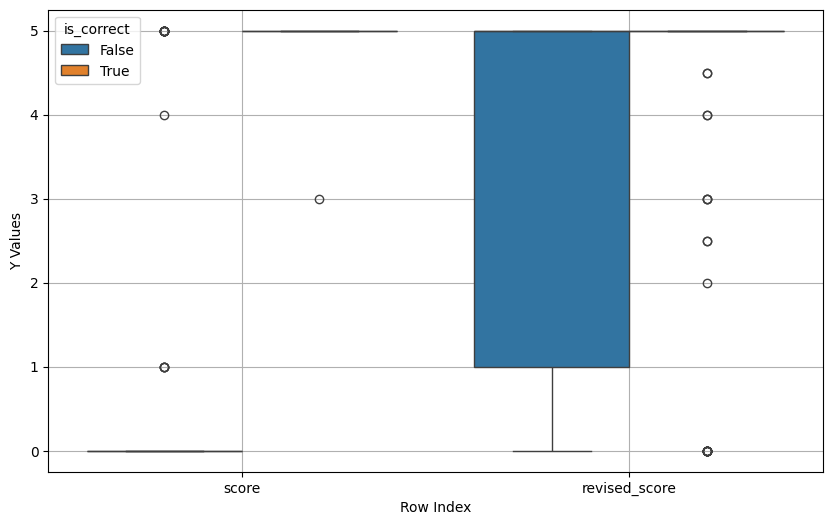

In [93]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.boxplot(
    data=df_long,
    x='line_name',        # Use the reset index for the x-axis
    y='score_value',
    hue='is_correct',  # Different colors for 'line1_data' and 'line2_data'
)

plt.xlabel('Row Index')
plt.ylabel('Y Values')
plt.legend(title='is_correct')
plt.grid(True)
plt.show()

# Autorater score histograms

Another way to view it.

As expected, the revised_score shifts all the scores towards 5.0 since it's rewriting is_correct == False statements to True.

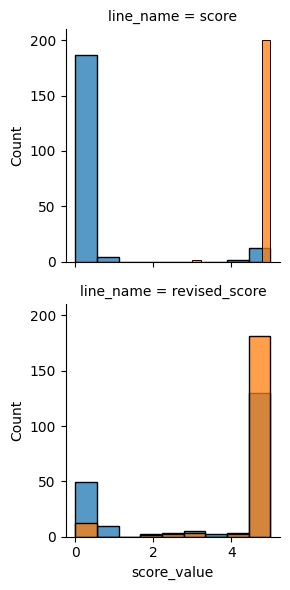

In [94]:
g = sns.FacetGrid(data=df_long, col='line_name', hue="is_correct", col_wrap=1)
g.map(sns.histplot, 'score_value')

In [95]:
df_long.groupby(["line_name", "is_correct"])["score_value"].mean()

line_name      is_correct
revised_score  False         3.446078
               True          4.616915
score          False         0.333333
               True          4.990050
Name: score_value, dtype: float64

In [96]:
df_long.groupby(["line_name", "is_correct"])["score_value"].std()


line_name      is_correct
revised_score  False         2.172269
               True          1.237947
score          False         1.210246
               True          0.141069
Name: score_value, dtype: float64

## Improvement of revised_score over score

Let's show that baseline gets a score of X then after revision we get a score of Y > X.
Where the score is based on this prompt.

In [97]:
df_results["revised_score_is_higher"] = df_results["revised_score"] > df_results["score"]

In [98]:
len(df_results[df_results["revised_score_is_higher"]])/len(df_results)

0.36049382716049383

Percentage same or improved for is_correct == True

These were correct to begin with so not much change is expected.

In [99]:
len(df_results[df_results["revised_score_is_higher"] & df_results["is_correct"]])/len(df_results[df_results["is_correct"]])

0.004975124378109453

Percentage same or improved for is_supported == False.


This is what we really care about, which is the ability of critique-reviser agent to "correct" non-supported answers into supported answers.

In [100]:
len(df_results[df_results["revised_score_is_higher"] & ~df_results["is_correct"]])/len(df_results[df_results["is_correct"]])

0.7213930348258707

We also want a guardrail to prevent is_correct = True statements from being scored low post-revision

This number is ideally close to 0

In [101]:
len(df_results[(df_results["revised_score"] < 5) & df_results["is_correct"]])/len(df_results[df_results["is_correct"]])

0.10945273631840796

### Visual representation

This is harder to read and probably less useful

<Axes: xlabel='revised_score_is_higher', ylabel='Count'>

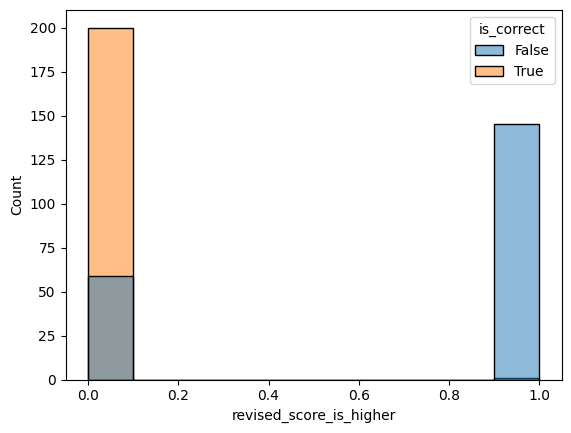

In [102]:
sns.histplot(data=df_results, x="revised_score_is_higher", hue="is_correct")

# Examine mistakes

Score expected to be higher (since it was revised) but it's not higher

In [103]:
df_results[~df_results["revised_score_is_higher"] & ~df_results["is_correct"]]

,question,answer,context,score,reason,is_correct,revised_answer,revised_score,revised_reason,revision_trace,critique_trace,revised_score_is_higher
0,How much did the BMW Group report in trade pay...,"The BMW Group reported €8,644 million in trade...",BALANCE SHEET FOR GROUP \nAND SEGMENTS AT 31...,0.0,The generated response is incorrect. It states...,False,The BMW Group's 2021 trade payables figure is ...,0.0,The generated response is completely incorrect...,"{\n ""claims_verification"": [\n {\n ""c...","Okay, I will verify the claim ""The BMW Group r...",False
2,What was the amount of subscribed share capita...,The amount of subscribed share capital increas...,Accumulated other equity\nin € million NoteSub...,0.0,The generated response is incorrect. According...,False,The amount of subscribed share capital increas...,0.0,The generated response is incorrect. According...,"{\n ""claims_verification"": [\n {\n ""c...",The amount of subscribed share capital increas...,False
9,How much cash was used in financing activities...,"Apple Inc. used $86,820 million for financing ...",Apple Inc.\nCONSOLIDATED STATEMENTS OF CASH FL...,0.0,The generated response is incorrect. According...,False,"Yes, Apple Inc. used $86,820 million for finan...",0.0,The generated response is incorrect. It states...,"{\n ""claims_verification"": [\n {\n ""c...","Yes, Apple Inc. used $86,820 million for finan...",False
22,What was the net change in unrealized loss fro...,The net change in unrealized loss from availab...,Table of Contents\nNVIDIA CORPORATION AND SUBS...,0.0,The generated response is incorrect. It states...,False,The net change in unrealized loss from availab...,0.0,The generated response is incorrect. It states...,"{\n ""claims_verification"": [\n {\n ""c...","Based on the provided sources, I can verify th...",False
23,What was the result from equity accounted inve...,The result from equity accounted investments f...,INCOME STATEMENT \nFOR GROUP AND SEGMENTS\nGr...,0.0,The generated response is incorrect. According...,False,The result from equity accounted investments f...,0.0,The generated response is incorrect. The groun...,"{\n ""claims_verification"": [\n {\n ""c...",I will verify the claim that the result from e...,False
27,How much did NVIDIA Corporation spend on Resea...,"NVIDIA Corporation spent $5,268 million on Res...",Table of Contents\nNVIDIA CORPORATION AND SUBS...,5.0,The generated response is correct and aligns p...,False,"NVIDIA Corporation spent $5,268 million on Res...",1.0,The generated response provides the figure for...,"{\n ""claims_verification"": [\n {\n ""c...","Based on the provided sources, NVIDIA Corporat...",False
39,What was the net income of Apple Inc. in 2021?,"The net income of Apple Inc. in 2021 was $57,4...",Apple Inc.\nCONSOLIDATED STATEMENTS OF COMPREH...,4.0,The generated response provides an accurate an...,False,"The net income of Apple Inc. in 2021 was $94,6...",2.0,The generated response correctly identifies wa...,"{\n ""claims_verification"": [\n {\n ""c...","The net income of Apple Inc. in 2021 was $94,6...",False
40,What was the total Accumulated other equity of...,The total Accumulated other equity of BMW Grou...,Accumulated other equity\nin € million NoteSub...,5.0,The generated response is correct. The ground ...,False,The total Accumulated other equity of BMW Grou...,5.0,The generated response is perfectly accurate. ...,"{\n ""claims_verification"": [\n {\n ""c...",The provided sources contain the following inf...,False
51,What was the total accumulated other comprehen...,The total accumulated other comprehensive inco...,Apple Inc.\nCONSOLIDATED STATEMENTS OF SHAREHO...,0.0,The generated response is incorrect. It states...,False,"Based on the provided sources, the accumulated...",0.0,The generated response is incorrect. It states...,"{\n ""claims_verification"": [\n {\n ""claim"":...","Based on the provided sources, the accumulated...",False
61,How much dividends and dividend equivalents pe...,Ap

# Dive into questions

In [104]:
df.columns

Index(['Questions', 'Answers', 'Contexts', 'Document', 'Page_no', 'Year',
       'Sector', 'Entity', 'Document_Type', 'Quarter', 'Page_No_Full_Doc'],
      dtype='object')

Examine samples where revised_score did not improve on an incorrect answer.

In [105]:
for _, row in df_results[(df_results["revised_score"] <= df_results["score"]) & (~df_results["is_correct"])].sample(3).iterrows():
    print(f"question: {row.question}\n\tbefore ({row.score}): {row.answer}\n\tafter ({row.revised_score}): {row.revised_answer.strip()}\n\tactual: {df[df['Questions'] == row.question]['Answers'].iloc[0]}\n")

question: What was the total Retained earnings of Mercedes-Benz Group at the end of 2022?
	before (0.0): The total Retained earnings of Mercedes-Benz Group at the end of 2022 was 14,501 million euros.
	after (0.0): The total Retained earnings of Mercedes-Benz Group at the end of 2022 was 14,501 million euros.
	actual: €67,695 million

question: How much cash was used in financing activities by Apple Inc. in 2019?
	before (0.0): Apple Inc. used $86,820 million for financing activities in 2019.
	after (0.0): Yes, Apple Inc. used $86,820 million for financing activities in 2019.
	actual: $90,976 million

question: What were the proceeds generated by BMW Group from the disposal of intangible assets and property, plant and equipment in 2020?
	before (0.0): The proceeds generated by BMW Group from the disposal of intangible assets and property, plant and equipment in 2020 were €1,328 million.
	after (0.0): The proceeds generated by BMW Group from the disposal of intangible assets and propert

Examine samples where correct answer was not scored high.

In [106]:
# for _, row in df_results[(df_results["revised_score"] <= 4.0) & (df_results["is_correct"])].sample(3).iterrows():
#     print(f"question: {row.question}\n\tbefore ({row.score}): {row.answer}\n\tafter ({row.revised_score}): {row.r evised_answer.strip()}\n\tactual: {df[df['Questions'] == row.question]['Answers'].iloc[0]}\n\trevision_trace: {row.revision_trace}\n\n")

In [ ]:
# for _, row in df_results[df_results["critique_trace"].str.contains("VERDICT: Accurate")].sample(1).iterrows():
#     actual_answer = df[df['Questions'] == row.question]['Answers'].iloc[0]

#     print(
#         f"question: {row.question}\n"
#         f"\tbefore ({row.score}): {row.answer}\n"
#         f"\tafter ({row.revised_score}): {row.revised_answer.strip()}\n"
#         f"\tactual: {actual_answer}\n"
#         # f"\tcontext: {row.context}\n"
#         f"\trevision_trace: {row.revision_trace}\n\n"
#         f"\tcritique_trace: {row.critique_trace}\n\n"
#     )

question: What was the total comprehensive income of Mercedes-Benz Group in 2022?
	before (5.0): The total comprehensive income of Mercedes-Benz Group in 2022 was 19,146 million euros.
	after (5.0): The total comprehensive income of Mercedes-Benz Group in 2022 was 19,146 million euros.
	actual: 19,146 million euros
	revision_trace: {
  "claims_verification": [
    {
      "claim": "The total comprehensive income of Mercedes-Benz Group in 2022 was 19,146 million euros.",
      "answer_part": "The total comprehensive income of Mercedes-Benz Group in 2022 was 19,146 million euros.",
      "verdict": "Accurate",
      "justification": "According to source [6], \"Total comprehensive income (restated)\" for 2022 was 19,146 million euros."
    }
  ],
  "overall_assessment": {
    "overall_verdict": "Accurate",
    "overall_justification": "The single claim was found to be accurate based on the provided source. The answer successfully addresses the question."
  }
}

	critique_trace: Okay, I wi

In [109]:
for _, row in df_results[(df_results["revised_score"] < df_results["score"]) & (df_results["is_correct"])].sample(3).iterrows():
    actual_answer = df[df['Questions'] == row.question]['Answers'].iloc[0]

    print(
        f"question: {row.question}\n"
        f"\tbefore ({row.score}): {row.answer}\n"
        f"\tafter ({row.revised_score}): {row.revised_answer.strip()}\n"
        f"\tactual: {actual_answer}\n"
        # f"\tcontext: {row.context}\n"
        f"\trevision_trace: {row.revision_trace}\n\n"
        f"\tcritique_trace: {row.critique_trace}\n\n"
    )


question: What were the total current liabilities of the BMW Group in 2021?
	before (5.0): The total current liabilities of the BMW Group in 2021 were €76,466 million.
	after (0.0): The total current liabilities of the BMW Group in 2021 were €15,718.801 million.
	actual: €76,466 million
	revision_trace: {
  "claims_verification": [
    {
      "claim": "The total current liabilities of the BMW Group in 2021 were €76,466 million.",
      "answer_part": "The total current liabilities of the BMW Group in 2021 were €76,466 million.",
      "verdict": "Inaccurate",
      "justification": "The provided sources, particularly source [9], which contains the balance sheet for the BMW Group at 31 December 2021, indicates that the total current liabilities were €15,718.801 million, not €76,466 million."
    }
  ],
  "overall_assessment": {
    "overall_verdict": "Inaccurate",
    "overall_justification": "The single claim is inaccurate based on the provided sources, which state the total current l